Found 46400 images belonging to 29 classes.
Found 11600 images belonging to 29 classes.
Epoch 1/20
300/300 [==============================] - 773s 3s/step - loss: 2.9759 - accuracy: 0.2636 - val_loss: 2.4960 - val_accuracy: 0.4640 - lr: 1.0000e-04
Epoch 2/20
300/300 [==============================] - 739s 2s/step - loss: 2.1484 - accuracy: 0.4848 - val_loss: 1.7093 - val_accuracy: 0.6710 - lr: 1.0000e-04
Epoch 3/20
300/300 [==============================] - 713s 2s/step - loss: 1.8950 - accuracy: 0.5813 - val_loss: 1.5079 - val_accuracy: 0.7281 - lr: 1.0000e-04
Epoch 4/20
300/300 [==============================] - 694s 2s/step - loss: 1.7306 - accuracy: 0.6370 - val_loss: 1.4567 - val_accuracy: 0.7391 - lr: 1.0000e-04
Epoch 5/20
300/300 [==============================] - 691s 2s/step - loss: 1.6395 - accuracy: 0.6777 - val_loss: 1.3828 - val_accuracy: 0.7674 - lr: 1.0000e-04
Epoch 6/20
300/300 [==============================] - 685s 2s/step - loss: 1.5495 - accuracy: 0.7089 - val_loss:

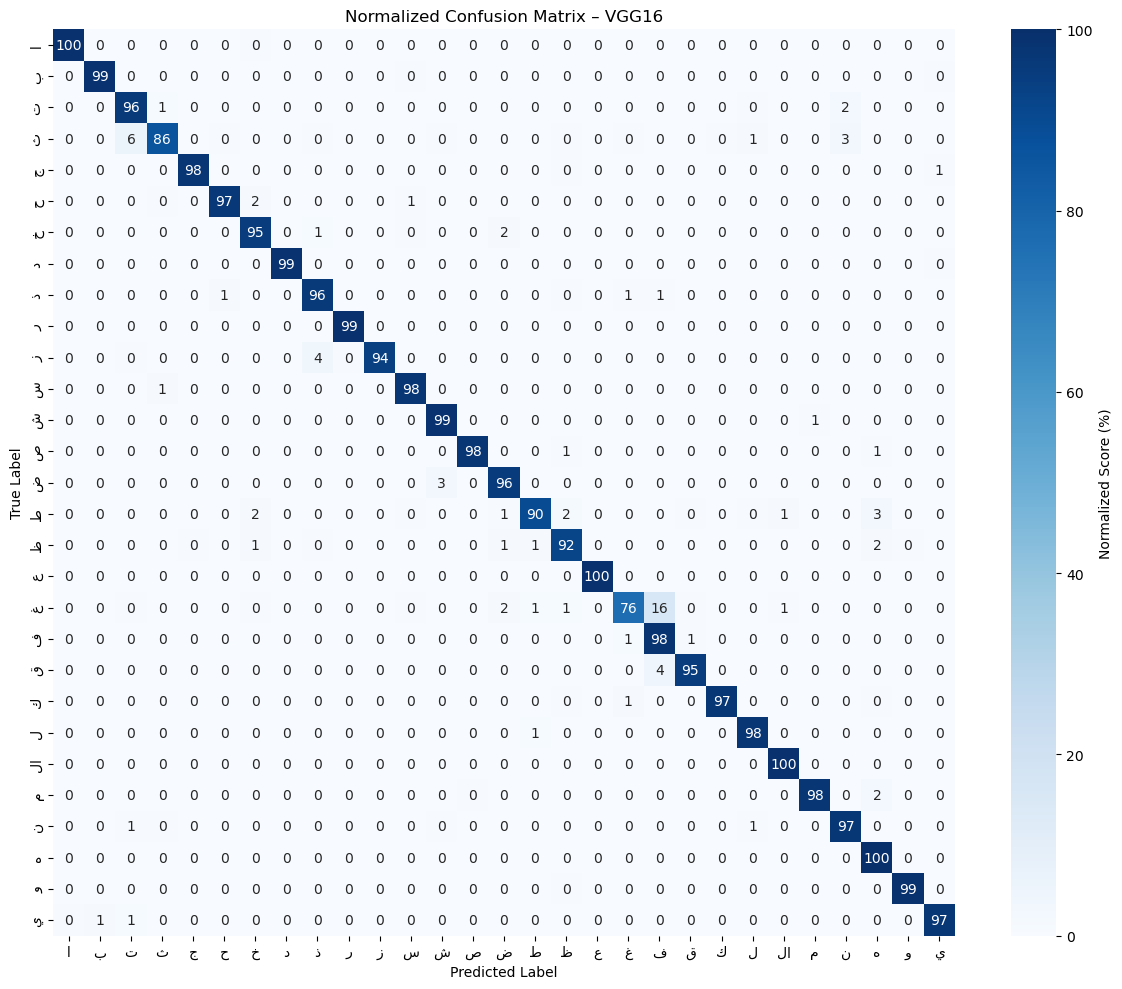

Classification Report:
               precision    recall  f1-score   support

           ا     0.9851    0.9950    0.9900       400
           ب     0.9850    0.9875    0.9863       400
           ت     0.9165    0.9600    0.9377       400
           ث     0.9582    0.8600    0.9065       400
           ج     0.9899    0.9800    0.9849       400
           ح     0.9724    0.9675    0.9699       400
           خ     0.9476    0.9500    0.9488       400
           د     0.9975    0.9875    0.9925       400
           ذ     0.9343    0.9600    0.9470       400
           ر     0.9802    0.9925    0.9863       400
           ز     0.9973    0.9400    0.9678       400
           س     0.9678    0.9775    0.9726       400
           ش     0.9427    0.9875    0.9646       400
           ص     0.9898    0.9750    0.9824       400
           ض     0.9386    0.9550    0.9467       400
           ط     0.9573    0.8975    0.9265       400
           ظ     0.9320    0.9250    0.9285       400
   

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import plot_model

# === Settings ===
data_dir = r"E:\cnndatasets\char_4K_sample\2000"
img_size = (64, 64)
batch_size = 32
num_classes = 29
initial_epochs = 20
fine_tune_epochs = 10
steps_per_epoch = 300  # limits training steps (adjust for speed)

# === LR Schedule ===
def lr_schedule(epoch, lr):
    if epoch < 10:
        return 1e-4
    elif epoch < 15:
        return 5e-5
    else:
        return 1e-5

# === Data Augmentation ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.9, 1.1),
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training', shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation', shuffle=False
)

# === Model: VGG16 ===
base_model = VGG16(include_top=False, weights='imagenet', input_shape=img_size + (3,))
base_model.trainable = False

inputs = Input(shape=img_size + (3,))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(lr_schedule)

# === Initial Training ===
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=initial_epochs,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# === Fine-tune last 4 layers ===
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# === Combine History ===
history = {}
for key in history1.history.keys():
    history[key] = history1.history[key] + history2.history.get(key, [])

# === Evaluate ===
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
chars = list(val_generator.class_indices.keys())

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
row_sums = cm.sum(axis=1, keepdims=True)
cm_scaled = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100

plt.figure(figsize=(12, 10))
sns.heatmap(cm_scaled, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=chars, yticklabels=chars,
            vmin=0, vmax=100, cbar_kws={'label': 'Normalized Score (%)'})
plt.title('Normalized Confusion Matrix – VGG16')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix_fast.png', dpi=300)
plt.show()

# === Classification Report ===
report_str = classification_report(y_true, y_pred_classes, target_names=chars, digits=4)
print("Classification Report:\n", report_str)

# === Metrics ===
print("✅ Metrics:")
print("Accuracy :", accuracy_score(y_true, y_pred_classes))
print("Precision:", precision_score(y_true, y_pred_classes, average='macro'))
print("Recall   :", recall_score(y_true, y_pred_classes, average='macro'))
print("F1 Score :", f1_score(y_true, y_pred_classes, average='macro'))

# === Training Plots ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("vgg16_training_fast.png", dpi=300)
plt.close()


Classification Report:
               precision    recall  f1-score   support

           ا     0.9851    0.9950    0.9900       400
           ب     0.9850    0.9875    0.9863       400
           ت     0.9165    0.9600    0.9377       400
           ث     0.9582    0.8600    0.9065       400
           ج     0.9899    0.9800    0.9849       400
           ح     0.9724    0.9675    0.9699       400
           خ     0.9476    0.9500    0.9488       400
           د     0.9975    0.9875    0.9925       400
           ذ     0.9343    0.9600    0.9470       400
           ر     0.9802    0.9925    0.9863       400
           ز     0.9973    0.9400    0.9678       400
           س     0.9678    0.9775    0.9726       400
           ش     0.9427    0.9875    0.9646       400
           ص     0.9898    0.9750    0.9824       400
           ض     0.9386    0.9550    0.9467       400
           ط     0.9573    0.8975    0.9265       400
           ظ     0.9320    0.9250    0.9285       400
   

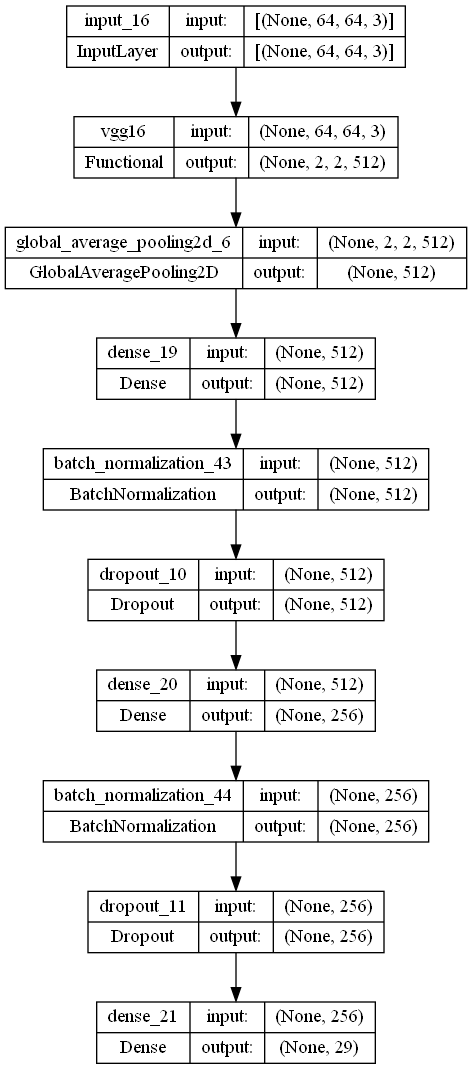

In [13]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === Classification Report ===
report_str = classification_report(y_true, y_pred_classes, target_names=chars, digits=4)
print("Classification Report:\n", report_str)

# Save report as image
report_dict = classification_report(y_true, y_pred_classes, target_names=chars, digits=4, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(12, 10))
sns.heatmap(df_report.iloc[:-3, :-1], annot=True, fmt=".4f", cmap="Blues")
plt.title("Classification Report (without support)")
plt.tight_layout()
plt.savefig("classification_report_fast.png", dpi=300)
plt.close()

# === Metrics ===
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print("✅ Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Save metrics as image
metrics = {
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
}
df_metrics = pd.DataFrame(metrics)

plt.figure(figsize=(6, 2))
sns.heatmap(df_metrics, annot=True, fmt=".4f", cmap="Greens", cbar=False)
plt.title("Evaluation Metrics")
plt.tight_layout()
plt.savefig("metrics_summary.png", dpi=300)
plt.close()

# === Save Model Structure ===
plot_model(model, to_file="Vgg16_model_structure_fast.png", show_shapes=True, show_layer_names=True)


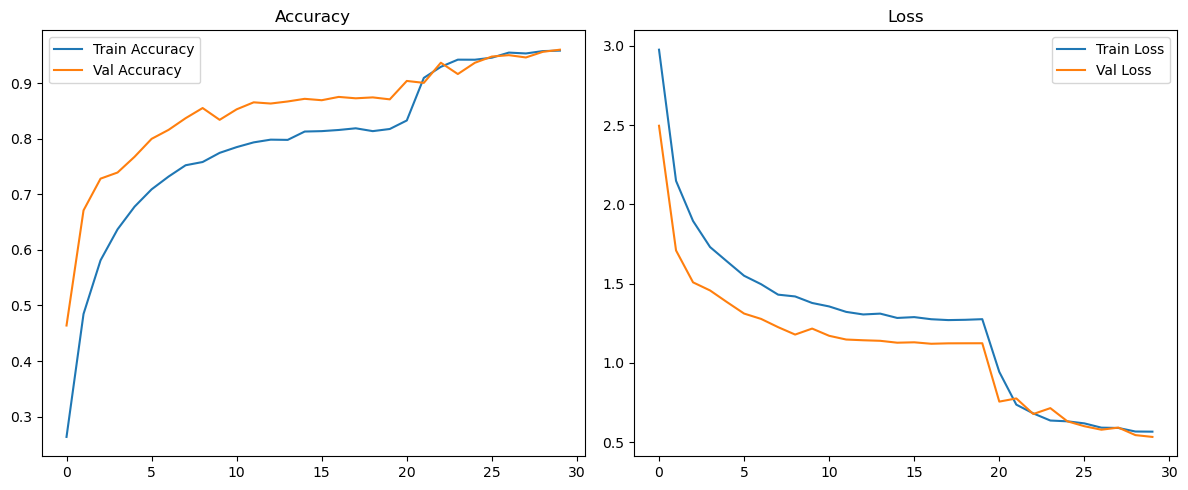

In [14]:
# === Training Plots ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("vgg16_training_fast.png", dpi=300)

# 👇 This line displays the plot on screen
plt.show()

plt.close()


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==== Config ====
IMAGE_SIZE = 64
NUM_CLASSES = 29
BATCH_SIZE = 64
EPOCHS = 30  # Fast training
STEPS_PER_EPOCH = 300   # To reduce training time
VALIDATION_STEPS = 50

# ==== Data Paths ====
train_dir = r"E:\cnndatasets\train"
val_dir = r"E:\cnndatasets\val"

# ==== Data Loaders ====
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# ==== Build Fast VGG16 Model ====
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
base_model.trainable = False  # Freeze all layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ==== Callbacks ====
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=1, min_lr=1e-6),
    ModelCheckpoint("vgg16_fast_model555.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ==== Train (5–8 mins) ====
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)


Found 115364 images belonging to 29 classes.
Found 28830 images belonging to 29 classes.
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 2, 2, 512)         14714688  
                                                                 
 global_average_pooling2d_2  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_6 (Dense)             (None, 128)               65664     
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 29)                3741      
                                                                 
Total params: 14784093 (56.40 M

KeyboardInterrupt: 

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==== Config ====
IMAGE_SIZE = 64
NUM_CLASSES = 29
BATCH_SIZE = 64
EPOCHS_PHASE1 = 25   # Fast phase
EPOCHS_PHASE2 = 10   # Fine-tuning phase
STEPS_PER_EPOCH = 300
VALIDATION_STEPS = 50

# ==== Data Paths ====
train_dir = r"E:\cnndatasets\train"
val_dir = r"E:\cnndatasets\val"

# ==== Data Generators ====
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# ==== Build Model ====
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
base_model.trainable = False  # Phase 1: freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ==== Callbacks ====
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=1, min_lr=1e-6),
    ModelCheckpoint("vgg16_best_model555.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ==== Train Phase 1 ====
print("\n==== PHASE 1: Fast Training with Frozen Base ====\n")
history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)

# ==== Fine-Tuning Phase 2 ====
print("\n==== PHASE 2: Fine-Tuning Top Layers ====\n")
base_model.trainable = True
# Freeze first 10 layers only (fine-tune last few blocks)
for layer in base_model.layers[:10]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE2,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)


Found 115364 images belonging to 29 classes.
Found 28830 images belonging to 29 classes.
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 2, 2, 512)         14714688  
                                                                 
 global_average_pooling2d_5  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_12 (Dense)            (None, 128)               65664     
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_13 (Dense)            (None, 29)                3741      
                                                                 
Total params: 14784093 (56.40 M

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


300/300 [==============================] - ETA: 0s - loss: 1.1635 - accuracy: 0.6977
Epoch 2: val_accuracy improved from 0.66500 to 0.80344, saving model to vgg16_best_model555.h5
300/300 [==============================] - 744s 2s/step - loss: 1.1635 - accuracy: 0.6977 - val_loss: 0.9490 - val_accuracy: 0.8034 - lr: 0.0010
Epoch 3/25
300/300 [==============================] - ETA: 0s - loss: 0.8721 - accuracy: 0.7735
Epoch 3: val_accuracy improved from 0.80344 to 0.84281, saving model to vgg16_best_model555.h5
300/300 [==============================] - 739s 2s/step - loss: 0.8721 - accuracy: 0.7735 - val_loss: 0.7169 - val_accuracy: 0.8428 - lr: 0.0010
Epoch 4/25
300/300 [==============================] - ETA: 0s - loss: 0.7332 - accuracy: 0.8098
Epoch 4: val_accuracy did not improve from 0.84281
300/300 [==============================] - 733s 2s/step - loss: 0.7332 - accuracy: 0.8098 - val_loss: 0.7116 - val_accuracy: 0.8231 - lr: 0.0010
Epoch 5/25
300/300 [===========================

451/451 [==============================] - 940s 2s/step
              precision    recall  f1-score   support

           ا       0.99      0.99      0.99      1000
           ب       0.97      0.97      0.97      1000
           ت       0.96      0.95      0.96      1000
           ث       0.92      0.91      0.92       897
           ج       0.99      0.96      0.98       944
           ح       0.99      0.93      0.96       628
           خ       0.94      0.96      0.95       775
           د       0.99      0.96      0.97      1000
           ذ       0.97      0.98      0.97      1000
           ر       0.96      0.98      0.97      1000
           ز       0.97      0.97      0.97      1000
           س       0.91      0.96      0.94      1000
           ش       0.95      0.97      0.96      1000
           ص       0.99      0.95      0.97      1000
           ض       0.97      0.95      0.96      1000
           ط       0.91      0.95      0.93      1000
           ظ       0.92  

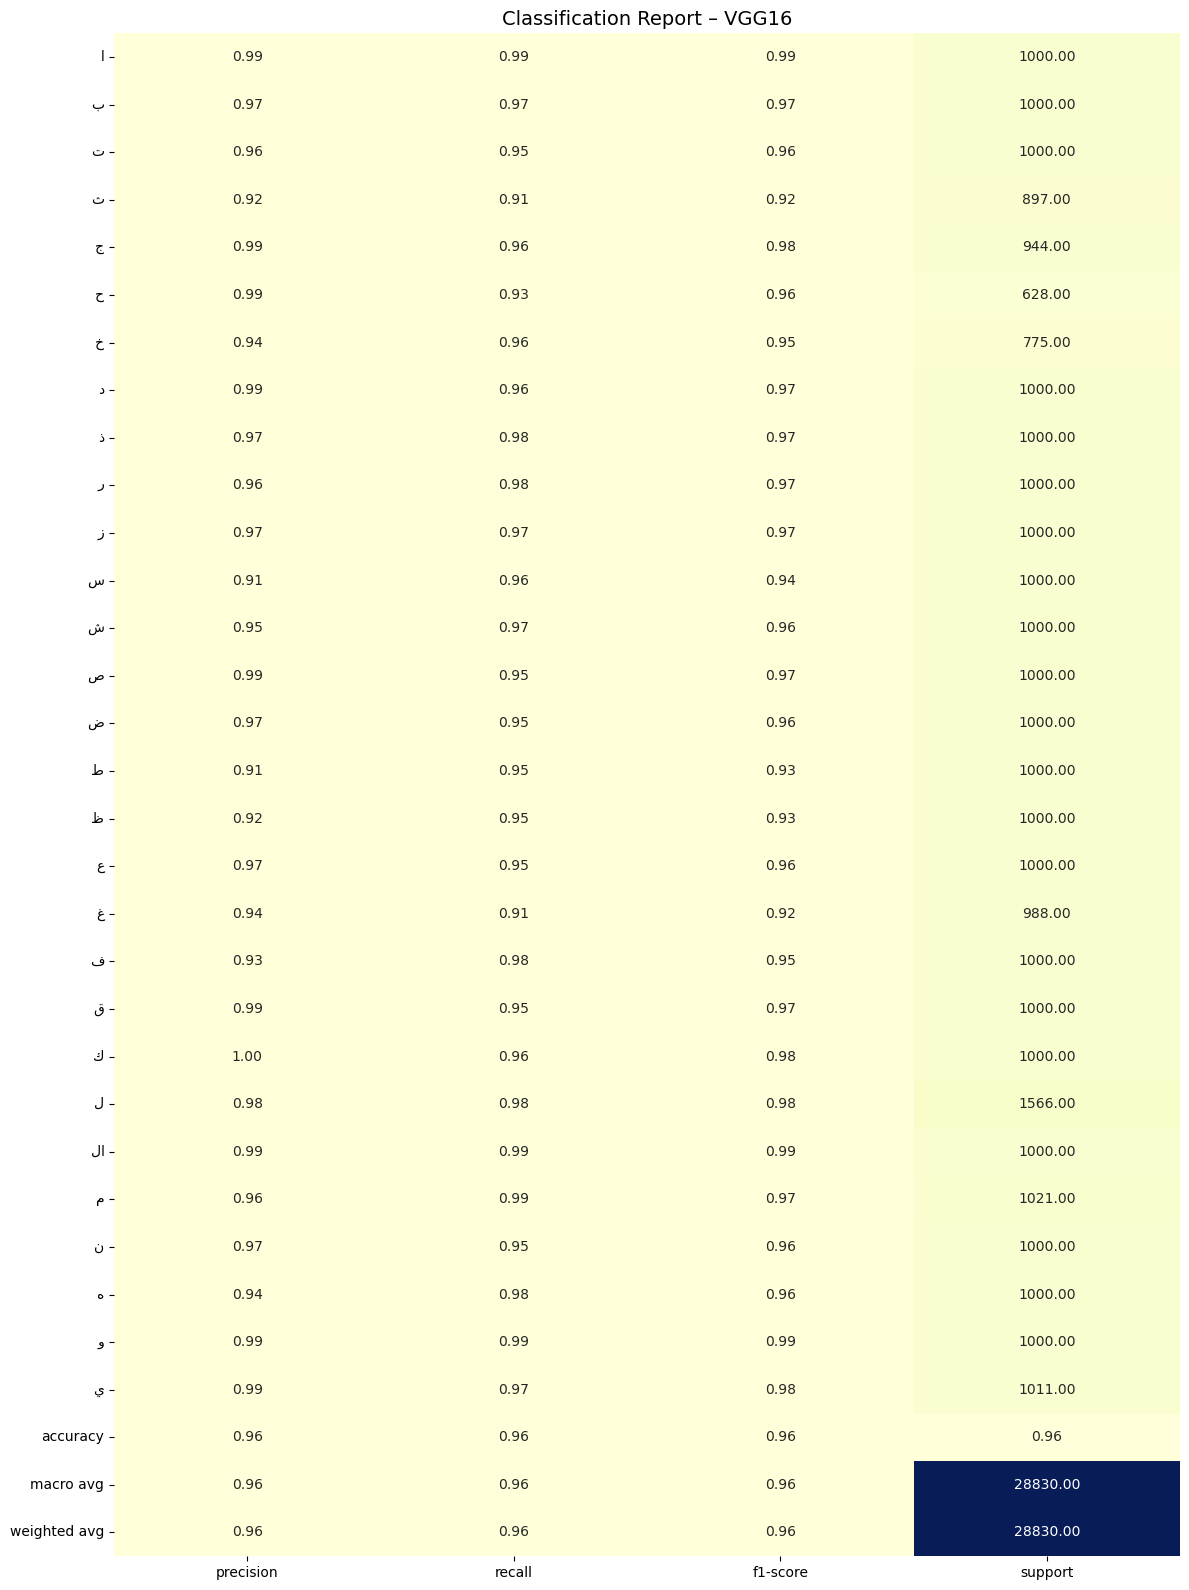

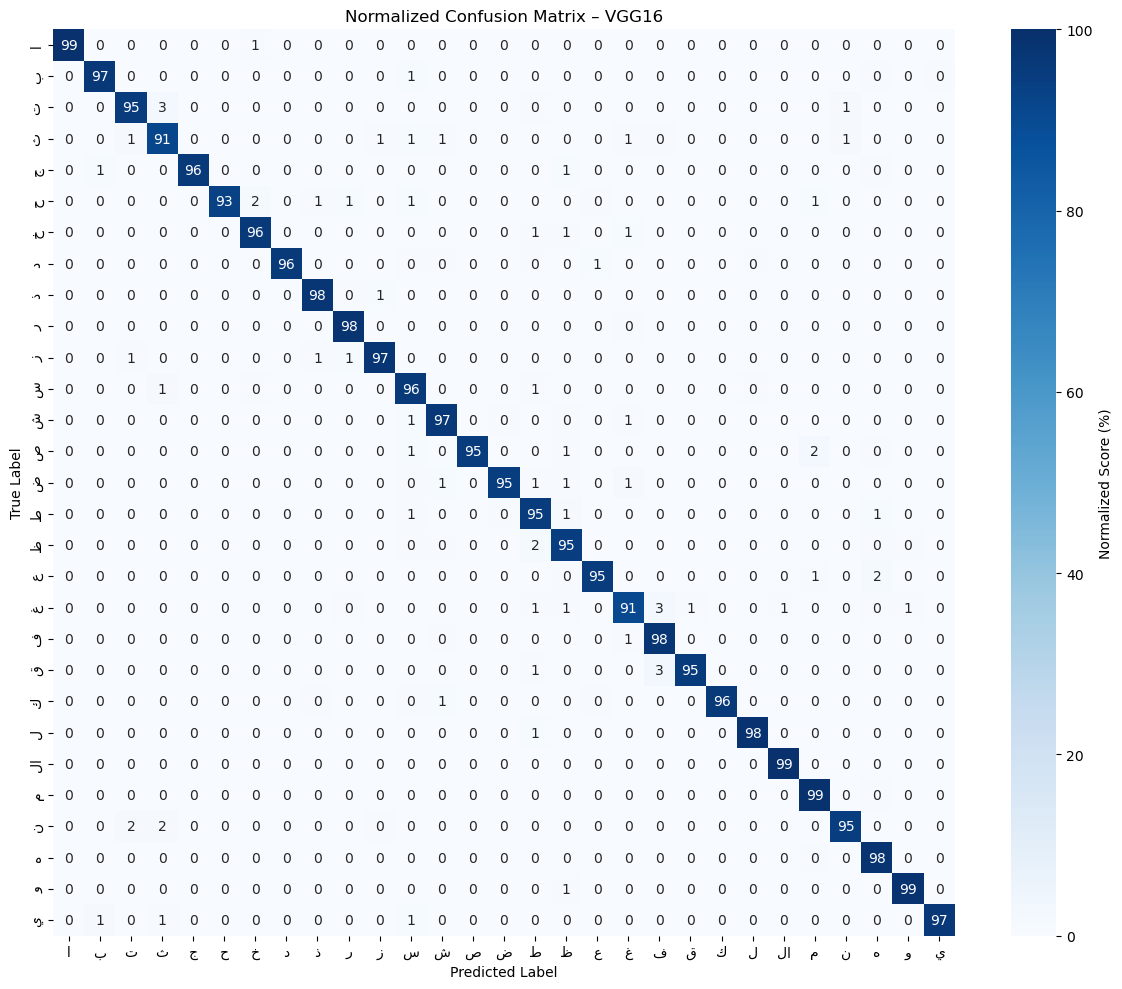

Final Validation Accuracy: 0.9630


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.utils import plot_model
import pandas as pd

# === 1. Plot Training History ===
def plot_training_history(history1, history2):
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('training_history_vgg16_555.png', dpi=300)
    plt.show()

# === 2. Plot Model Structure ===
plot_model(model, to_file='vgg16_model_structure_555.png', show_shapes=True, show_layer_names=True)

# === 3. Predict and Evaluate ===
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
chars = list(val_gen.class_indices.keys())  # Arabic labels

# === 4. Classification Report (Text + Image) ===
report_dict = classification_report(y_true, y_pred_classes, target_names=chars, output_dict=True)
report_text = classification_report(y_true, y_pred_classes, target_names=chars)
print(report_text)

# Save as text file
with open("classification_report_vgg16_555.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

# Save as image
df_report = pd.DataFrame(report_dict).transpose()
plt.figure(figsize=(12, len(df_report) * 0.5))
sns.heatmap(df_report.iloc[:, :4], annot=True, fmt=".2f", cmap="YlGnBu", cbar=False)
plt.title("Classification Report – VGG16", fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("classification_report_vgg16_555.png", dpi=300)
plt.show()

# === 5. Normalized Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred_classes)
row_sums = cm.sum(axis=1, keepdims=True)
cm_scaled = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100

plt.figure(figsize=(12, 10))
sns.heatmap(cm_scaled, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=chars, yticklabels=chars,
            vmin=0, vmax=100, cbar_kws={'label': 'Normalized Score (%)'})
plt.title('Normalized Confusion Matrix – VGG16')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix_fast_555.png', dpi=300)
plt.show()

# === 6. Overall Accuracy ===
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Final Validation Accuracy: {accuracy:.4f}")


In [15]:
import matplotlib.pyplot as plt

def plot_training_history(history1, history2):
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()

    # Save and show
    plt.savefig('training_history_vgg16_555.png', dpi=300)
    plt.show()
    print("✅ Saved as training_history_vgg16_555.png")


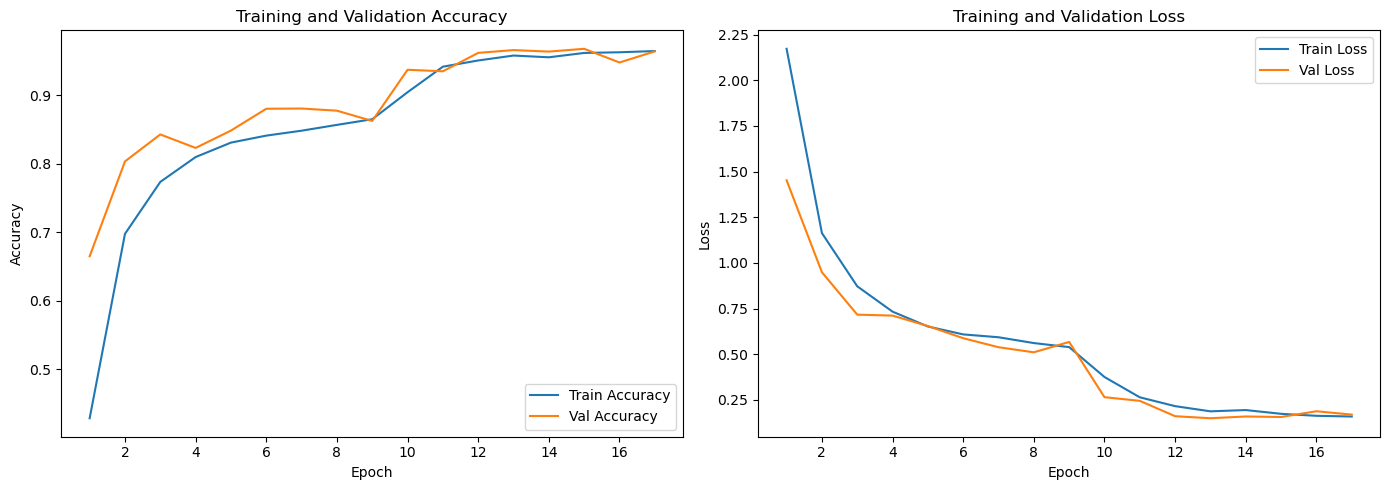

✅ Saved as training_history_vgg16_555.png


In [16]:
plot_training_history(history_phase1, history_phase2)


In [18]:
plt.savefig('training_history_vgg16.png', dpi=300)


<Figure size 640x480 with 0 Axes>